In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [88]:
import pandas as pd

# Load the dataset
df = pd.read_csv('ADANIPORTS.NS (1).csv')

# Check the first few rows to ensure it's loaded correctly
print(df.head())


         Date        Open        High         Low       Close   Adj Close  \
0  2019-08-22  348.799988  348.799988  340.799988  345.049988  332.896515   
1  2019-08-23  346.399994  354.149994  339.649994  349.350006  337.045105   
2  2019-08-26  366.000000  375.000000  349.350006  368.200012  355.231140   
3  2019-08-27  370.299988  374.250000  367.299988  372.049988  358.945526   
4  2019-08-28  373.100006  374.250000  364.049988  365.950012  353.060455   

    Volume  
0  2171160  
1  2246560  
2  4974219  
3  3040184  
4  2186454  


In [89]:
# Ensure the 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows where the 'Date' column could not be converted
df = df[df['Date'].notna()]

# Extract Day, Month, and Year from the 'Date' column
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Display the updated data with Day, Month, and Year columns
print(df.head())


        Date        Open        High         Low       Close   Adj Close  \
0 2019-08-22  348.799988  348.799988  340.799988  345.049988  332.896515   
1 2019-08-23  346.399994  354.149994  339.649994  349.350006  337.045105   
2 2019-08-26  366.000000  375.000000  349.350006  368.200012  355.231140   
3 2019-08-27  370.299988  374.250000  367.299988  372.049988  358.945526   
4 2019-08-28  373.100006  374.250000  364.049988  365.950012  353.060455   

    Volume  Day  Month  Year  
0  2171160   22      8  2019  
1  2246560   23      8  2019  
2  4974219   26      8  2019  
3  3040184   27      8  2019  
4  2186454   28      8  2019  


In [90]:
# Drop the 'Date' column
df.drop(columns=['Date'], inplace=True)

# Display the updated data to confirm the 'Date' column has been removed
print(df.head())


         Open        High         Low       Close   Adj Close   Volume  Day  \
0  348.799988  348.799988  340.799988  345.049988  332.896515  2171160   22   
1  346.399994  354.149994  339.649994  349.350006  337.045105  2246560   23   
2  366.000000  375.000000  349.350006  368.200012  355.231140  4974219   26   
3  370.299988  374.250000  367.299988  372.049988  358.945526  3040184   27   
4  373.100006  374.250000  364.049988  365.950012  353.060455  2186454   28   

   Month  Year  
0      8  2019  
1      8  2019  
2      8  2019  
3      8  2019  
4      8  2019  


In [91]:
df.shape  # Get the number of rows and columns


(1236, 9)

In [92]:
# Check for missing values
print(df.isnull().sum())


Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Day          0
Month        0
Year         0
dtype: int64


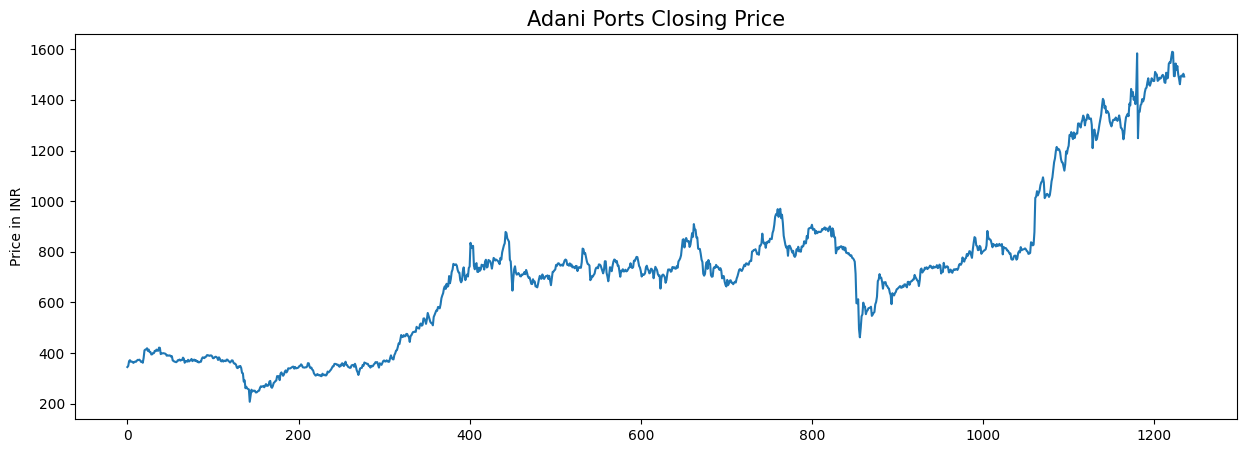

In [93]:
# Plotting the Adani Ports Closing Price
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title('Adani Ports Closing Price', fontsize=15)
plt.ylabel('Price in INR')
plt.show()


In [94]:
df[df['Close'] == df['Adj Close']].shape

(47, 9)

In [95]:
# Select only numeric columns
numeric_columns = df.select_dtypes(include=[np.number])

# Calculate the IQR for each numeric column
Q1 = numeric_columns.quantile(0.25)
Q3 = numeric_columns.quantile(0.75)
IQR = Q3 - Q1

# Define outlier condition
outliers = ((numeric_columns < (Q1 - 1.5 * IQR)) | (numeric_columns > (Q3 + 1.5 * IQR)))

# Find outliers for each numeric feature
outliers_summary = outliers.sum()

# Display outliers count for each column
print("Outliers in each numeric column:\n", outliers_summary)


Outliers in each numeric column:
 Open          50
High          50
Low           48
Close         51
Adj Close     50
Volume       110
Day            0
Month          0
Year           0
dtype: int64


In [96]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Calculate the IQR for each numeric column
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define a filter to remove outliers
filter_outliers = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

# Apply the filter to remove outliers
df_cleaned = df[filter_outliers]

# Check the shape of the original and cleaned dataset
print(f"Original data shape: {df.shape}")
print(f"Cleaned data shape: {df_cleaned.shape}")


Original data shape: (1236, 9)
Cleaned data shape: (1076, 9)


In [97]:
# Add a 7-day moving average
df['7-day MA'] = df['Close'].rolling(window=7).mean()

# Drop rows with missing values (due to rolling calculation)
df.dropna(inplace=True)

# Display the updated dataset
print(df.head())


          Open        High         Low       Close   Adj Close   Volume  Day  \
6   368.450012  368.850006  359.399994  365.700012  352.819244  2313806   30   
7   362.700012  367.149994  359.549988  361.299988  348.574219  1638833    3   
8   361.299988  365.750000  356.649994  364.350006  351.516785  1846644    4   
9   365.700012  367.750000  361.250000  366.549988  353.639282  1642165    5   
10  368.000000  368.700012  363.799988  365.750000  352.867462  2366109    6   

    Month  Year    7-day MA  
6       8  2019  361.785719  
7       9  2019  364.107147  
8       9  2019  366.250004  
9       9  2019  366.014287  
10      9  2019  365.114288  


In [99]:
# Calculate correlation between numeric columns
correlation_matrix = data.corr()

# Display the correlation matrix
print(correlation_matrix)

# Optional: Visualize the correlation matrix using a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix')
plt.show()


NameError: name 'data' is not defined